# Taller análisis descriptivo de variables cualitativas

Se va a trabajar con un dataset que contiene información sobre incidentes de tránsito en Medellín con víctimas.

Cárguelo y verifique que se haya cargado correctamente.

In [125]:
import pandas as pd

df = pd.read_csv("/content/Accidentes de tránsito en Medellín.csv")
df.head()

,Fecha_incidente,Gravedad_victima,Clase_incidente,Sexo,Condicion,Grupo_edad,Comuna,Barrio,Dia_semana,Mes,Año
0,2014-01-01,Heridos,Otro,M,Motociclista,10 - 19,04 - Aranjuez,Manrique Central No. 1,Miércoles,Enero,2014
1,2014-01-01,Heridos,Atropello,M,Motociclista,20 - 29,01 - Popular,Moscú No. 2,Miércoles,Enero,2014
2,2014-01-01,Heridos,Atropello,F,Peatón,10 - 19,01 - Popular,Moscú No. 2,Miércoles,Enero,2014
3,2014-01-01,Heridos,Atropello,M,Motociclista,10 - 19,16 - Belén,Las Mercedes,Miércoles,Enero,2014
4,2014-01-01,Heridos,Atropello,M,Peatón,30 - 39,16 - Belén,Las Mercedes,Miércoles,Enero,2014


La variable "Fecha_incidente" debe convertirse a dato de tiempo.

Excluya los datos del año 2021.

In [126]:
df['Fecha_incidente'] = pd.to_datetime(df['Fecha_incidente'])
df['Fecha_incidente'].dtype
df = df[df['Fecha_incidente'].dt.year != 2021]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 214116 entries, 0 to 214115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Fecha_incidente   214116 non-null  datetime64[ns]
 1   Gravedad_victima  214116 non-null  object        
 2   Clase_incidente   214116 non-null  object        
 3   Sexo              212482 non-null  object        
 4   Condicion         214116 non-null  object        
 5   Grupo_edad        211871 non-null  object        
 6   Comuna            195177 non-null  object        
 7   Barrio            195036 non-null  object        
 8   Dia_semana        214116 non-null  object        
 9   Mes               214116 non-null  object        
 10  Año               214116 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(9)
memory usage: 19.6+ MB


In [127]:
print(df['Fecha_incidente']) ## validacion de excluir el 2021

0        2014-01-01
1        2014-01-01
2        2014-01-01
3        2014-01-01
4        2014-01-01
            ...    
214111   2020-12-31
214112   2020-12-31
214113   2020-12-31
214114   2020-12-31
214115   2020-12-31
Name: Fecha_incidente, Length: 214116, dtype: datetime64[ns]


De acuerdo a lo visto en clase, indique qué tipo de variable es cada una de las que están en el DataFrame.

Convierta a "category" las variables categóricas, cuidando que las variables nominales y ordinales queden correctamente convertidas.

| Variable | Tipo |
|---|---|
| `Fecha_incidente` | Cuantitativa de intervalo |
| `Gravedad_victima` | Cualitativa ordinal |
| `Clase_incidente` | Cualitativa nominal |
| `Sexo` | Cualitativa nominal |
| `Condicion` | Cualitativa nominal |
| `Grupo_edad` | Cualitativa ordinal |
| `Comuna` | Cualitativa nominal |
| `Barrio` | Cualitativa nominal |
| `Dia_semana` | Cualitativa ordinal |
| `Mes` | Cualitativa ordinal |
| `Año` | Cuantitativa de intervalo ordinal |

In [128]:
nominales = ['Clase_incidente', 'Sexo', 'Condicion', 'Comuna', 'Barrio']
ordinales = ['Gravedad_victima', 'Grupo_edad', 'Dia_semana', 'Mes', 'Año']

# -- Nominales --
for c in nominales:
    df[c] = df[c].astype('category')

# -- Ordinales --
df['Gravedad_victima'] = pd.Categorical(
    df['Gravedad_victima'],
    categories=['Heridos', 'Muertos'],
    ordered=True)

df['Grupo_edad'] = pd.Categorical(
    df['Grupo_edad'],
    categories=['0 - 9', '10 - 19', '20 - 29', '30 - 39', '40 - 49',
                '50 - 59', '60 - 69', '70 - 79', '80 o más'],
    ordered=True)


df['Dia_semana'] = pd.Categorical(
    df['Dia_semana'],
    categories=['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo'],
    ordered=True)


df['Mes'] = pd.Categorical(
    df['Mes'],
    categories=['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio',
                'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre'],
    ordered=True)


df['Año'] = pd.Categorical(
    df['Año'],
    categories=sorted(df['Año'].unique()),
    ordered=True)


df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 214116 entries, 0 to 214115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Fecha_incidente   214116 non-null  datetime64[ns]
 1   Gravedad_victima  214116 non-null  category      
 2   Clase_incidente   214116 non-null  category      
 3   Sexo              212482 non-null  category      
 4   Condicion         214116 non-null  category      
 5   Grupo_edad        211871 non-null  category      
 6   Comuna            195177 non-null  category      
 7   Barrio            195036 non-null  category      
 8   Dia_semana        214116 non-null  category      
 9   Mes               214116 non-null  category      
 10  Año               214116 non-null  category      
dtypes: category(10), datetime64[ns](1)
memory usage: 5.5 MB


Identifique qué variable(s) tienen alta cardinalidad. Excluya esta(s) de los análisis posteriores.

In [129]:
cardinalidad = pd.Series(
    {c: df[c].nunique() for c in nominales + ordinales}
).sort_values(ascending=False)

print(cardinalidad.to_string())


Barrio              418
Comuna               21
Mes                  12
Grupo_edad            9
Dia_semana            7
Condicion             7
Año                   7
Clase_incidente       6
Sexo                  2
Gravedad_victima      2


Haga las tablas de frecuencias porcentuales de todas las variables categóricas.

Para cada variable, indique cuál es la categoría más frecuente y cuál la menos frecuente.

Identifique qué variables presentan categorías atípicas. Indique los nombres de las categorías atípicas.

In [130]:
## se excluye barrio
nominales = [c for c in nominales if c != 'Barrio']
categoricas = nominales + ordinales

print("Variables que se analizan:", categoricas)

Variables que se analizan: ['Clase_incidente', 'Sexo', 'Condicion', 'Comuna', 'Gravedad_victima', 'Grupo_edad', 'Dia_semana', 'Mes', 'Año']


In [131]:
def tabla_frecuencias(serie):
    """Tabla con frecuencia absoluta, relativa, porcentual y porcentual acumulada."""
    absoluta = serie.value_counts(sort=False)
    relativa = serie.value_counts(normalize=True, sort=False)
    tabla = pd.DataFrame({
        'Frec. absoluta': absoluta,
        'Frec. relativa': relativa.round(4),
        'Frec. %': (100 * relativa).round(2),
        'Frec. % acumulada': (100 * relativa).cumsum().round(2),
    })
    return tabla

# Para las nominales el orden por frecuencia descendente es más legible.
# Se reordena antes de acumular, para que la columna acumulada tenga sentido de lectura.
def tabla_nominal(serie):
    orden = serie.value_counts().index
    t = tabla_frecuencias(serie).loc[orden]
    t['Frec. % acumulada'] = t['Frec. %'].cumsum().round(2)
    return t

for c in nominales:
    print(f"\n===== {c}  (nominal) =====")
    print(tabla_nominal(df[c]).to_string())


===== Clase_incidente  (nominal) =====
                 Frec. absoluta  Frec. relativa  Frec. %  Frec. % acumulada
Clase_incidente                                                            
Choque                    94148          0.4397    43.97              43.97
Otro                      36902          0.1723    17.23              61.20
Atropello                 36316          0.1696    16.96              78.16
Caida Ocupante            32614          0.1523    15.23              93.39
Volcamiento               14114          0.0659     6.59              99.98
Incendio                     22          0.0001     0.01              99.99

===== Sexo  (nominal) =====
      Frec. absoluta  Frec. relativa  Frec. %  Frec. % acumulada
Sexo                                                            
M             147373          0.6936    69.36              69.36
F              65109          0.3064    30.64             100.00

===== Condicion  (nominal) =====
                            F

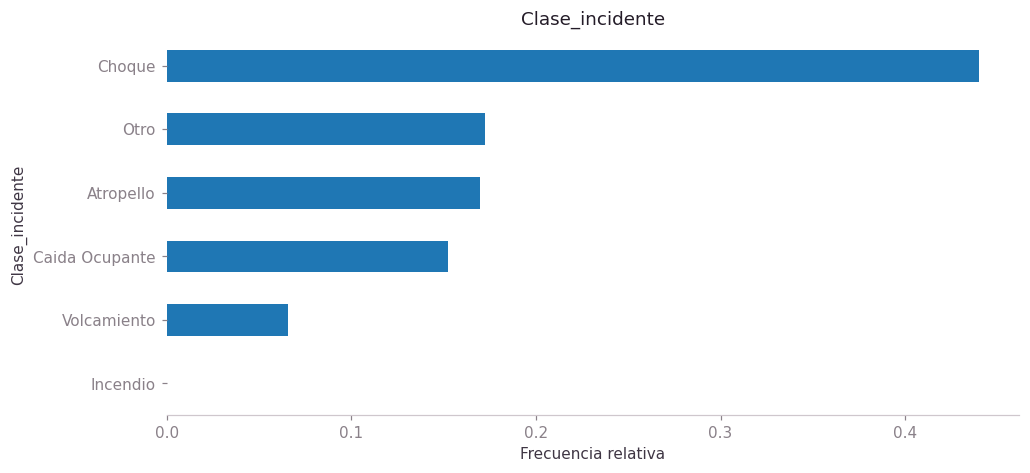

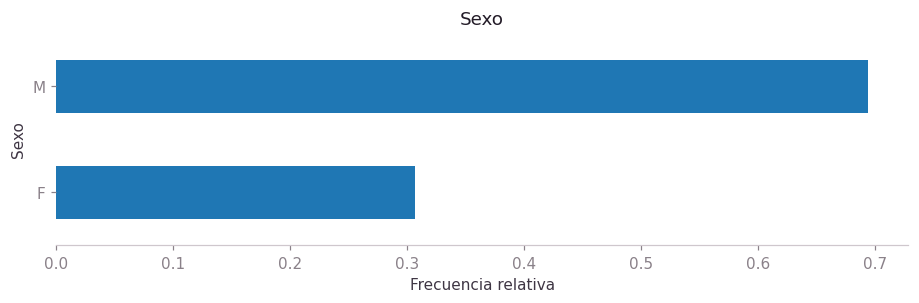

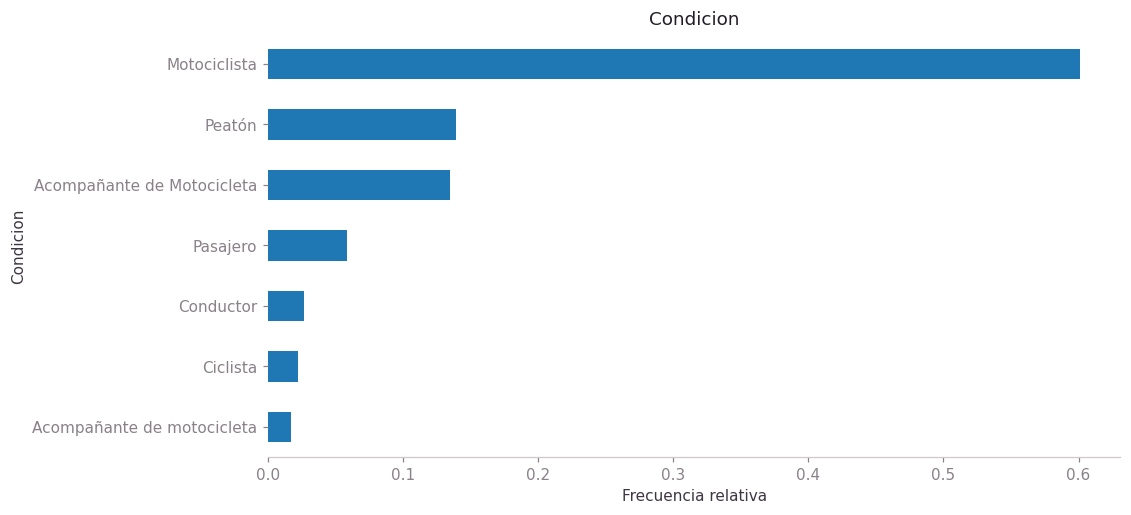

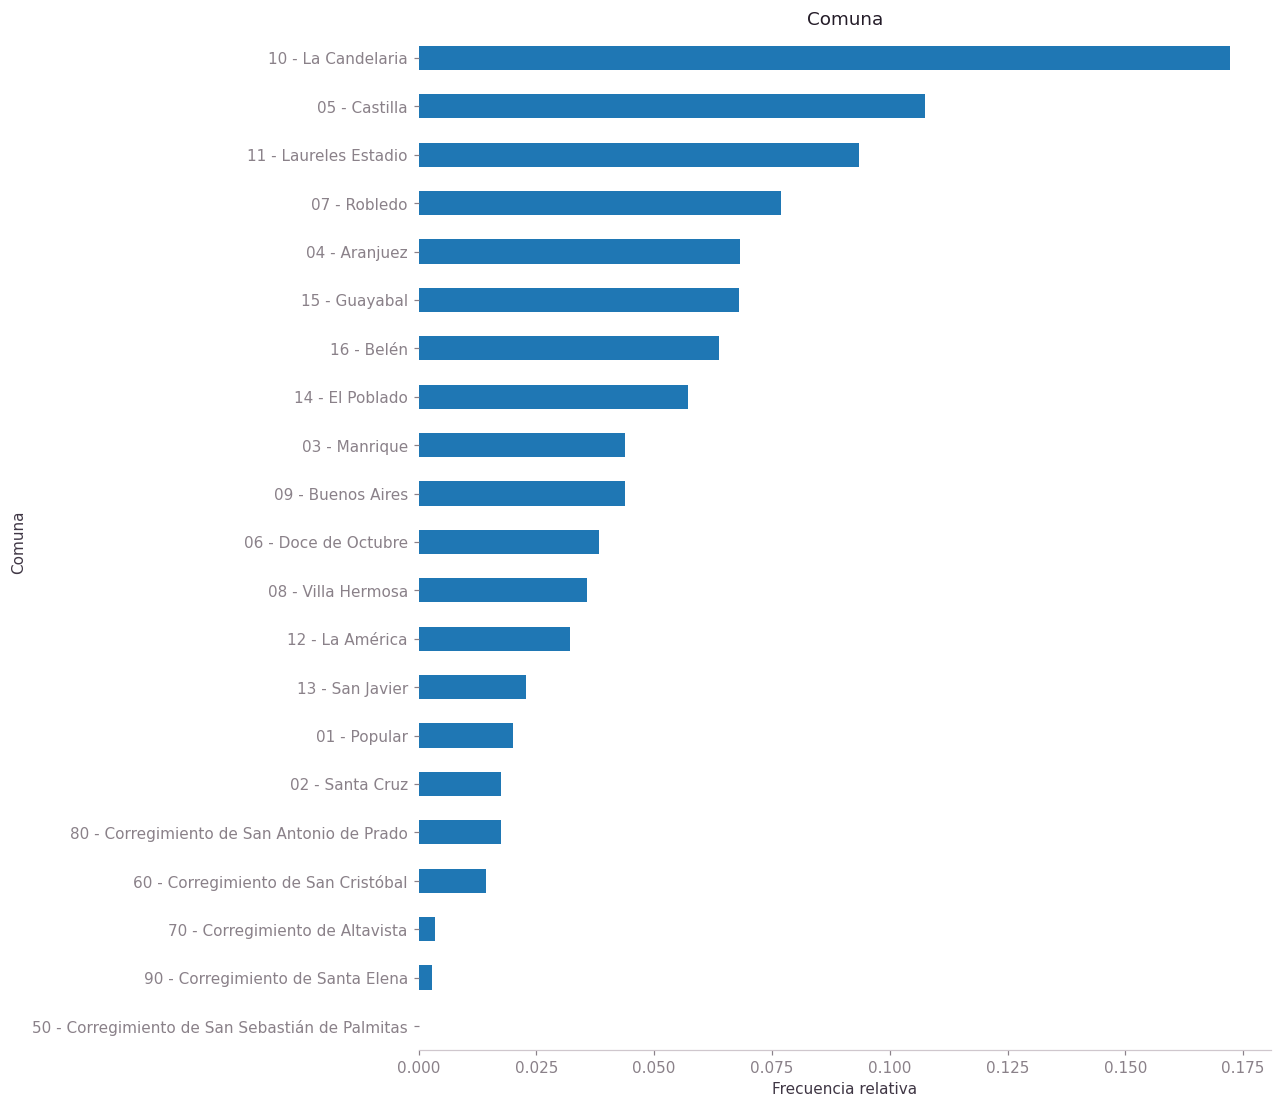

In [132]:
for c in nominales:
    frec = df[c].value_counts(normalize=True, ascending=True)
    frec.plot(kind='barh', figsize=(10, 0.5 * len(frec) + 1.5), title=c)
    plt.xlabel('Frecuencia relativa')
    plt.show()

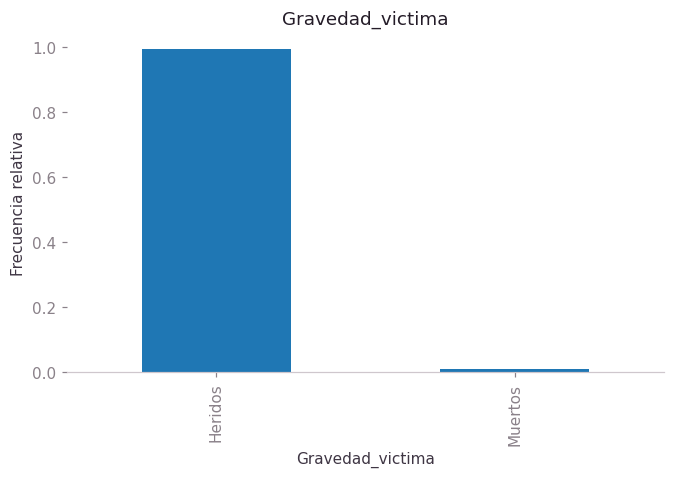

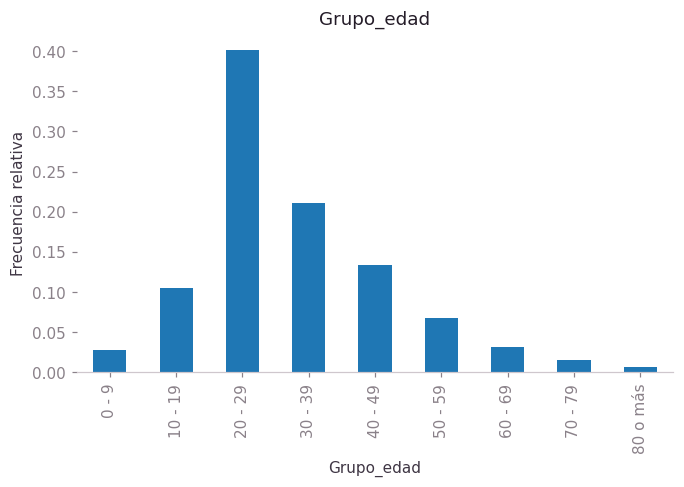

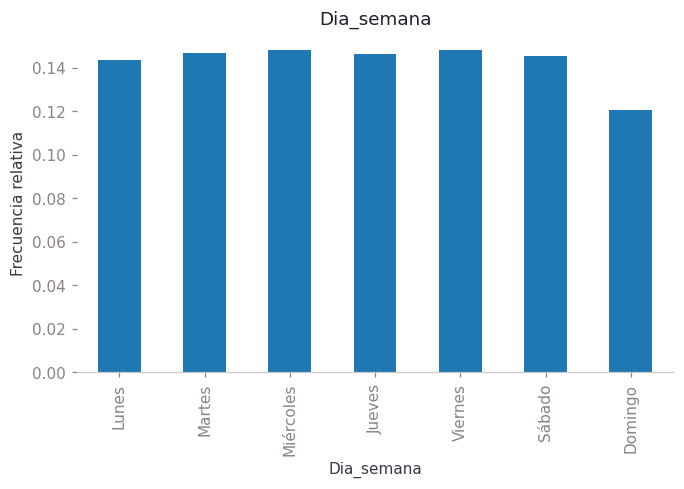

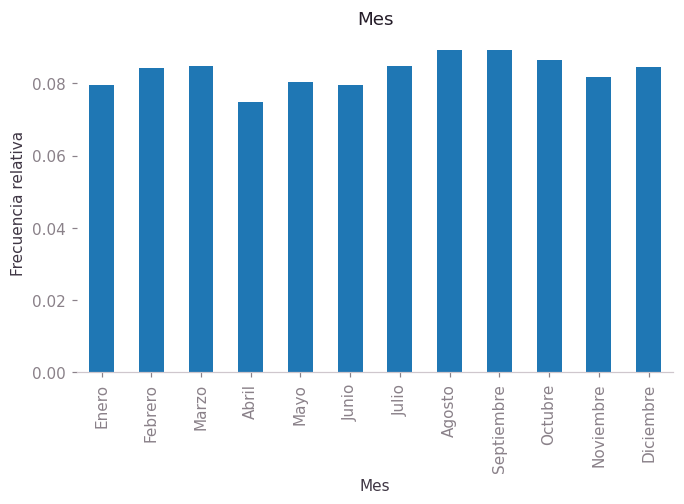

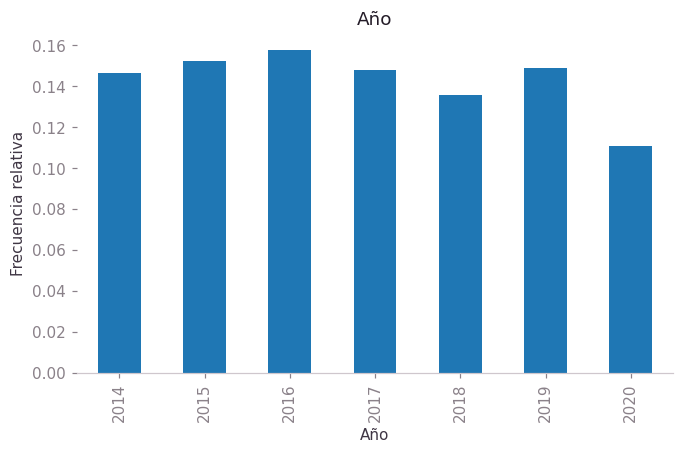

In [133]:
for c in ordinales:
    frec = df[c].value_counts(normalize=True, sort=False)
    frec.plot(kind='bar', figsize=(7, 4), title=c)
    plt.ylabel('Frecuencia relativa')
    plt.show()